## Evaluator-Optimizer

In the **Evaluator-Optimizer** workflow, one LLM call generate a response, while another provides evaluation and feedback in a loop. 

**When to use Evaluator-Optimizer workflow:** This workflow is particulary effective when we have clear evaluation criteria, and when iterative refinement provides measurable value. The two signs of good fit are: 
1. LLM response can be demonstrably improved when a human articulates their feedback.
2. LLM can provide such a feedback.

This is analogous to the iterative writing process a human writer might go through when producing a polished document.

In [1]:
import os
from dotenv import load_dotenv

ENV_PATH = '../.env'
assert os.path.exists(ENV_PATH)

load_dotenv('../.env')

GROQ_API_KEY = os.environ['GROQ_API_KEY']
assert GROQ_API_KEY
print(f'----> GROQ_API_KEY: {GROQ_API_KEY[:3]}***{GROQ_API_KEY[-3:]}')


LANGCHAIN_API_KEY = os.environ['LANGCHAIN_API_KEY']
assert LANGCHAIN_API_KEY
print(f'----> LANGCHAIN_API_KEY: {LANGCHAIN_API_KEY[:3]}***{LANGCHAIN_API_KEY[-3:]}')

# Required by LangChain 
os.environ['LANGCHAIN_TRACING_V2'] = 'true'
LANGCHAIN_PROJECT = 'Evaluator-Optimizer example'
os.environ['LANGCHAIN_PROJECT'] = LANGCHAIN_PROJECT
print(f'---->LANGCHAIN_PROJECT: {LANGCHAIN_PROJECT}')

----> GROQ_API_KEY: gsk***qNU
----> LANGCHAIN_API_KEY: lsv***43b
---->LANGCHAIN_PROJECT: Evaluator-Optimizer example


In [2]:
from langchain_groq import ChatGroq

#LLM temperature is a parameter that controls the randomness and creativity of a large language model's output by adjusting the probability distribution of next-word predictions. Lower temperatures (e.g., <0.5) make the output more predictable and deterministic, favoring more common, "safer" words, which is good for factual accuracy. Higher temperatures (e.g., >0.8) increase randomness, leading to more varied, creative, and surprising outputs, ideal for tasks like brainstorming or storytelling. 
llm = ChatGroq(model='qwen/qwen3-32b', temperature=0, reasoning_format='hidden')
llm

ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x106bbea50>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x106bbf620>, model_name='qwen/qwen3-32b', temperature=1e-08, reasoning_format='hidden', model_kwargs={}, groq_api_key=SecretStr('**********'))

#### Graph state

In [3]:
from typing_extensions import Literal, TypedDict
from pydantic import BaseModel, Field

# Graph state
class State(TypedDict):
    topic: str
    joke: str
    feedback: str
    funny_or_not: str

# Structured output for Evaluator
class Feedback(BaseModel):
    grade: Literal['funny', 'not_funny'] = Field(description='Decide if the joke is funny or not')
    feedback: str = Field(description='If the joke is NOT funny, provide feedback on how to improve it')

# Augment the LLM with structured output
evaluator = llm.with_structured_output(Feedback)

### Create the graph nodes

In [12]:
from langchain_core.messages import HumanMessage, SystemMessage

def generator(state: State) -> State:
    """LLM generates a joke"""
    generator_prompt = """
    You are a creative joke writer.  
    Your task is to generate original jokes that are short, clever, and easy to understand.  
    Jokes should be family-friendly and safe for all audiences.  
    You will be given:
    - a topic (optional)  
    - feedback from an evaluator (optional)  

    Instructions:  
    1. If feedback is provided, improve your joke according to the evaluator's suggestions.  
    2. Otherwise, generate a new joke based on the given topic (or a general joke if no topic is given).  
    3. Always return only the joke text — no explanations.
    4. Joke should be short, maximum 50 words.
    """

    human_message = f'Joke topic: {state["topic"]}\n'
    if 'feedback' in state and state["feedback"]:
        human_message += f'Feedbacl: {state["feedback"]}'

    input_messages = [
        SystemMessage(content=generator_prompt),
        HumanMessage(content=human_message)
    ]

    response = llm.invoke(input=input_messages)

    return { 'joke': response.content }


def evaluate(state: State) -> State:
    """LLM Evaluator of a Joke"""
    system_prompt = """
    You are a humor evaluator.  
    Your role is to review jokes generated by another model and provide clear, constructive feedback.  

    Instructions:  
    1. Evaluate the joke based on:  
    - Clarity (Is it easy to understand?)  
    - Originality (Is it unique or too common?)  
    - Humor (Is it actually funny, clever, or surprising?)  
    - Appropriateness (Is it safe for all audiences?)  
    2. Provide specific, actionable feedback the generator can use to improve the joke.  
    3. Do not rewrite the joke yourself — only give feedback.  
    4. Keep the feedback short and precise (1–3 sentences).   
    """

    input_messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=f'Joke: {state["joke"]}')
    ]

    eval_response: Feedback = evaluator.invoke(input=input_messages)
    return { 'feedback': eval_response.feedback, 'funny_or_not': eval_response.grade }

def acceptance_test(state: State) -> Literal['Accepted', 'Rejected']:
    if state['funny_or_not'] == 'funny':
        return 'Accepted'
    return 'Rejected'

### Build the graph

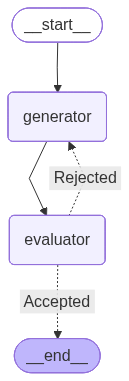

In [13]:
from IPython.display import display, Image
from langgraph.graph import StateGraph, START, END

graph_builder = StateGraph(State)

# Add nodes 
graph_builder.add_node('generator', generator)
graph_builder.add_node('evaluator', evaluate)

# Add edges
graph_builder.add_edge(START, 'generator')
graph_builder.add_edge('generator', 'evaluator')
graph_builder.add_conditional_edges('evaluator', acceptance_test, {
    'Accepted': END,
    'Rejected': 'generator'
})

graph = graph_builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))


In [14]:
input_state: State = {'topic': 'cats'}

response = graph.invoke(input=input_state)
response

{'topic': 'cats',
 'joke': "Cat tried caffeine to catch mice, now she's hyper and keeps knocking things off shelves. Guess who's cleaning up? The mice!",
 'feedback': 'The joke is clear and has a playful twist, but the setup is somewhat predictable. To improve, consider adding a more unexpected punchline or a clever wordplay to enhance originality and surprise.',
 'funny_or_not': 'funny'}